In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


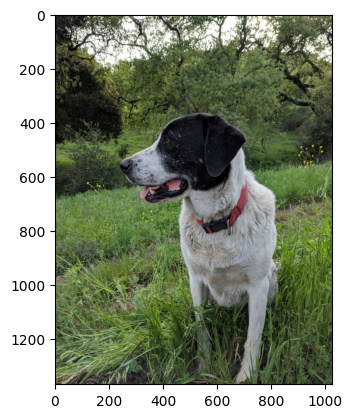

In [10]:
img = cv2.imread("sammy.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)

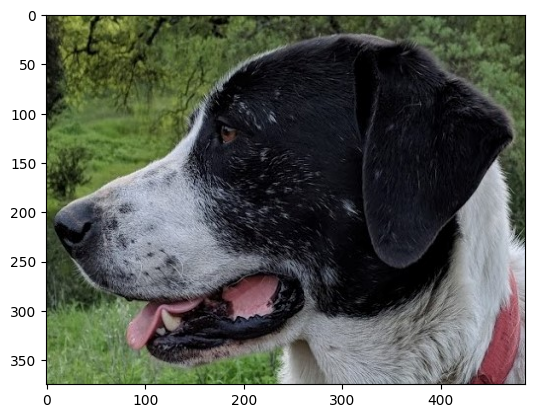

In [11]:
template = cv2.imread("sammy_face.jpg")
template=cv2.cvtColor(template,cv2.COLOR_BGR2RGB)
plt.imshow(template)

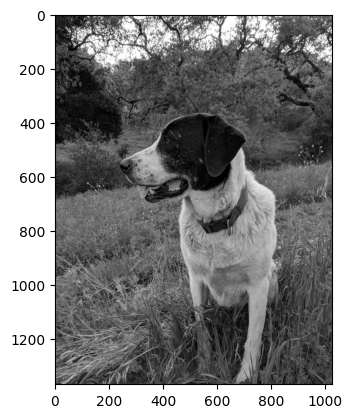

In [12]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray,cmap='gray')

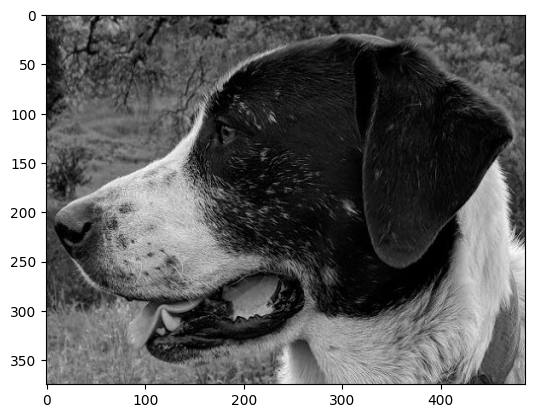

In [13]:
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
plt.imshow(template_gray,cmap='gray')

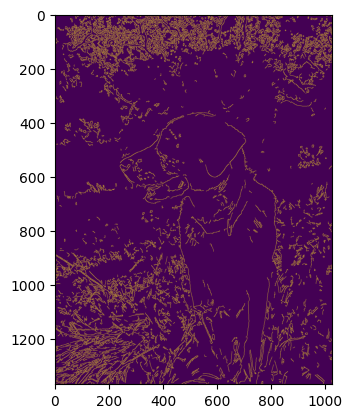

In [14]:
blur_img=cv2.GaussianBlur(img_gray,(5,5),0)
img_edge = cv2.Canny(blur_img, 100, 200)
plt.imshow(img_edge)

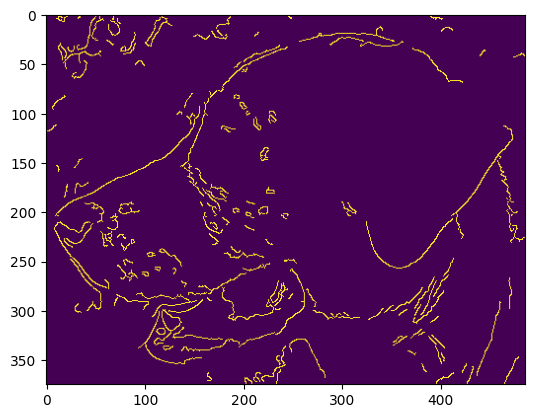

In [15]:
template_blur_img=cv2.GaussianBlur(template_gray,(5,5),0)
template_edge = cv2.Canny(template_blur_img, 100, 200)
plt.imshow(template_edge)

Method: cv2.TM_CCOEFF
Matching Score: 360181312.0
Objects detected: 1



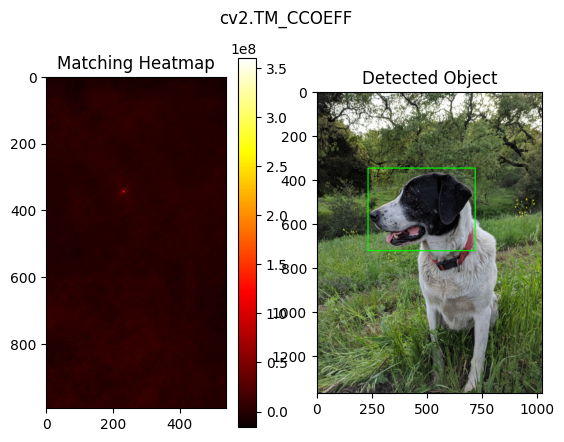

Method: cv2.TM_CCOEFF_NORMED
Matching Score: 0.9145564436912537
Objects detected: 1



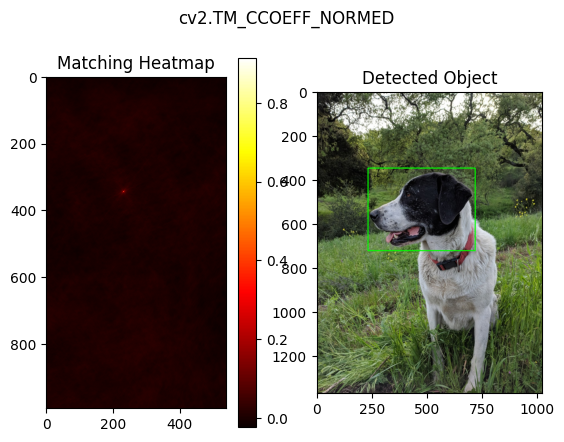

Method: cv2.TM_CCORR
Matching Score: 374218944.0
Objects detected: 1



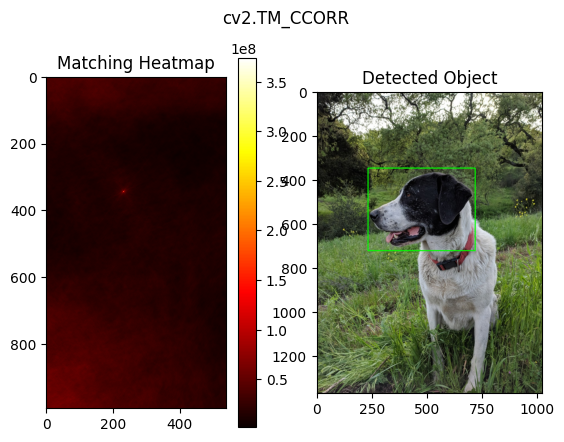

Method: cv2.TM_CCORR_NORMED
Matching Score: 0.9174971580505371
Objects detected: 1



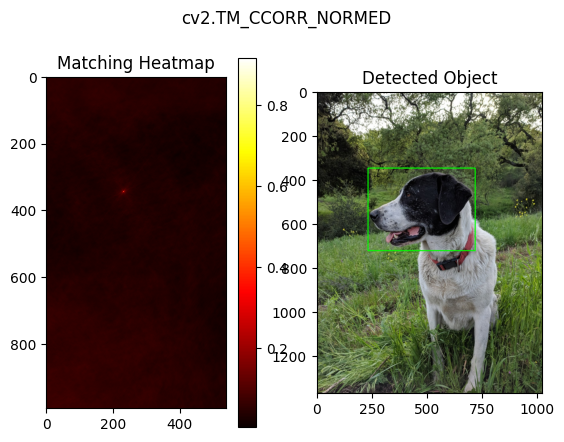

Method: cv2.TM_SQDIFF
Matching Score: 67300864.0
Objects detected: 1



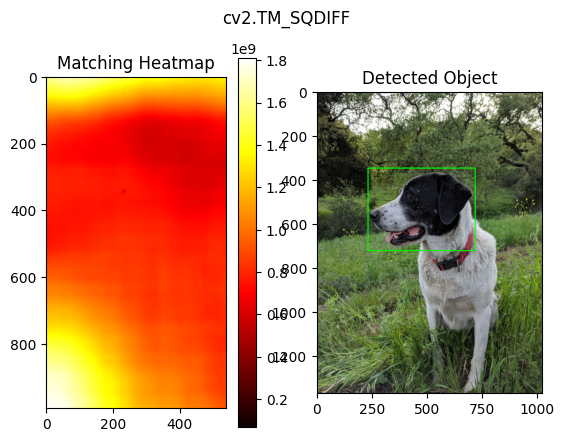

Method: cv2.TM_SQDIFF_NORMED
Matching Score: 0.1650056391954422
Objects detected: 1



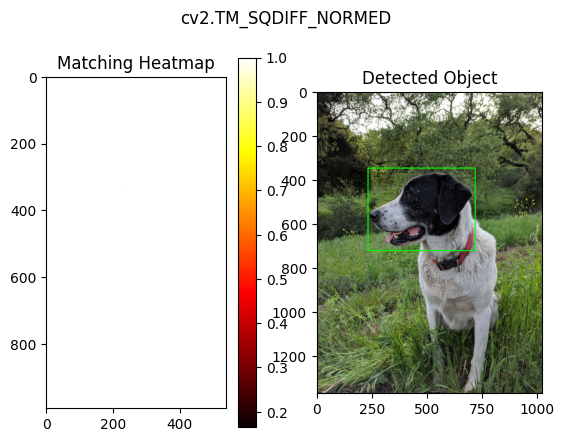

In [16]:
height, width = template_edge.shape
methods = [
    'cv2.TM_CCOEFF', 
    'cv2.TM_CCOEFF_NORMED',
    'cv2.TM_CCORR',
    'cv2.TM_CCORR_NORMED',
    'cv2.TM_SQDIFF',
    'cv2.TM_SQDIFF_NORMED'
]

for m in methods:

    img_copy = img.copy()
    method = eval(m)

    # Template Matching using edges
    res = cv2.matchTemplate(img_edge, template_edge, method)

    # Find best match
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    # Determine best location depending on method
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:

        top_left = min_loc
        score = min_val
        count = 1

    else:

        top_left = max_loc
        score = max_val
        count = 1

    # Draw rectangle
    bottom_right = (top_left[0] + width, top_left[1] + height)
    cv2.rectangle(img_copy, top_left, bottom_right, (0,255,0), 3)

    # Print results
    print("Method:", m)
    print("Matching Score:", score)
    print("Objects detected:", count)
    print()

    # Heatmap visualization
    plt.subplot(121)
    plt.imshow(res, cmap='hot')
    plt.colorbar()
    plt.title('Matching Heatmap')

    # Detection result
    plt.subplot(122)
    plt.imshow(img_copy)
    plt.title('Detected Object')

    plt.suptitle(m)

    plt.show()

  